In [1]:
# Make inline plots vector graphics instead of raster graphics
%matplotlib inline
from IPython.display import set_matplotlib_formats

set_matplotlib_formats("pdf", "svg")

# Plotting
import matplotlib.pyplot as plt

In [2]:
import numpy as np
from probnum.diffeq import probsolve_ivp

# 2-D damped oscillator (Linear)

In [3]:
def f(t, y):
    y1, y2 = y
    return np.array([-0.1*y1+2*y2, -2*y1-0.1*y2])


def df(t, y):
    y1, y2 = y
    return np.array([[-0.1, 2], [-2, -0.1]])


t0 = 0.0
tmax = 25.0
y0 = np.array([2, 0])

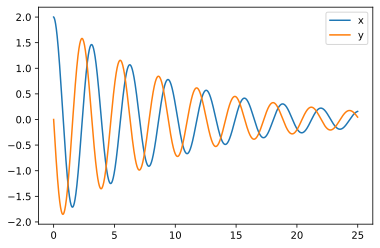

In [4]:
# IBM(1) with EK0,  solving an IVP with adaptive steps works.
sol = probsolve_ivp(f, t0, tmax, y0, df=df, algo_order=4, method="EK1")
dt=0.01
evalgrid = np.arange(0, 25, dt)
means = sol(evalgrid).mean

plt.plot(evalgrid, means[:, 0], label="x")
plt.plot(evalgrid, means[:, 1], label="y")
plt.legend(loc="upper right")
plt.show()

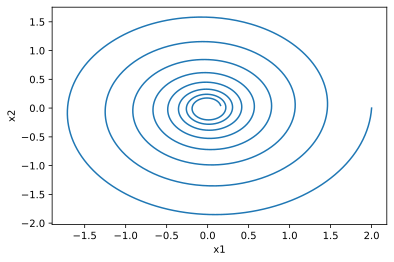

In [5]:
plt.plot(means[:, 0],means[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

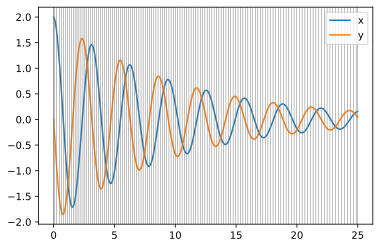

In [6]:
# Let’s visualise the individual steps.
plt.plot(evalgrid, means[:, 0], label="x")
plt.plot(evalgrid, means[:, 1], label="y")
for t in sol.locations:
    plt.axvline(t, linewidth=0.5, color="gray")
plt.legend(loc="upper right")
plt.show()

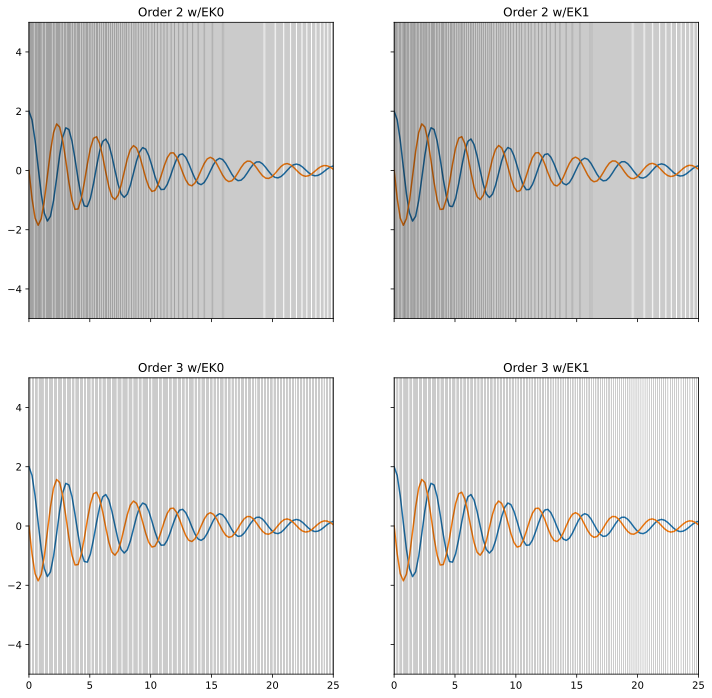

In [7]:
algo_orders = [2, 3]
filters = ["EK0", "EK1"]


fig, ax = plt.subplots(
    nrows=len(algo_orders),
    ncols=len(filters),
    sharex=True,
    sharey=True,
    figsize=(12, 12),
)

evalgrid = np.linspace(t0, tmax, 100)

for idx in range(len(algo_orders)):  # algo_orders in rows
    for jdx in range(len(filters)):  # filters in cols
        sol = probsolve_ivp(
            f,
            t0,
            tmax,
            y0,
            df=df,
            algo_order=algo_orders[idx],
            method=filters[jdx],
        )

        solution = sol(evalgrid)
        ts, means, stds = evalgrid, solution.mean, solution.std
        ax[idx][jdx].plot(ts, means)

        for t in sol.locations:
            ax[idx][jdx].axvline(t, linewidth=0.2, color="black")
        ax[idx][jdx].set_title(f"Order {algo_orders[idx]} w/{filters[jdx]}")
        ax[idx][jdx].set_xlim((t0, tmax))
        ax[idx][jdx].set_ylim((-5, 5))

plt.show()

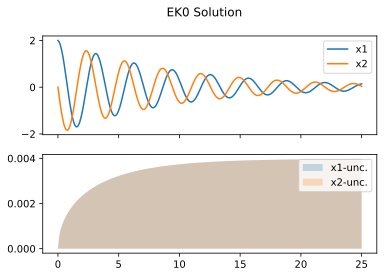

In [8]:
sol = probsolve_ivp(
    f, t0, tmax, y0, df=df, step=0.1, adaptive=False, diffusion_model="dynamic"
)

means, stds = sol.states.mean, sol.states.std

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
ax1.plot(sol.locations, means[:, 0], label="x1")
ax1.plot(sol.locations, means[:, 1], label="x2")
ax1.legend()
ax2.fill_between(sol.locations, stds[:, 0], alpha=0.25, label="x1-unc.")
ax2.fill_between(sol.locations, stds[:, 1], alpha=0.25, label="x2-unc.")
ax2.legend()
fig.suptitle("EK0 Solution")
plt.show()

In [9]:
sol = probsolve_ivp(
    f,
    t0,
    tmax,
    y0,
    df=df,
    step=0.5,
    algo_order=1,
    adaptive=False,
    diffusion_model="dynamic",
)

In [10]:
import numpy as np

from probnum.diffeq import probsolve_ivp


rng = np.random.default_rng(seed=123)

num_samples = 150
locations = np.arange(0.0, 22.1, 0.05)
locations = sol.locations
samples = sol.sample(rng=rng, t=locations, size=num_samples)

solution = sol(locations)
means = solution.mean
stds = solution.std

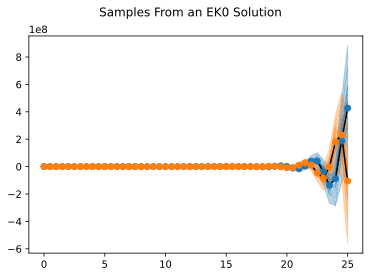

In [11]:
fig, (ax1) = plt.subplots(nrows=1, ncols=1, sharex=True)
for sample in samples[::5]:
    ax1.plot(locations, sample[:, 0], ":", color="C0", linewidth=0.5, alpha=1)
    ax1.plot(locations, sample[:, 1], ":", color="C1", linewidth=0.5, alpha=1)
ax1.plot(locations, means[:, 0], label="x1", color="k")
ax1.plot(locations, means[:, 1], label="x2", color="k")
ax1.fill_between(
    locations,
    means[:, 0] - 3 * stds[:, 0],
    means[:, 0] + 3 * stds[:, 0],
    color="C0",
    alpha=0.3,
)
ax1.fill_between(
    locations,
    means[:, 1] - 3 * stds[:, 1],
    means[:, 1] + 3 * stds[:, 1],
    color="C1",
    alpha=0.3,
)

ax1.plot(sol.locations, sol.states.mean, "o")
fig.suptitle(f"Samples From an EK0 Solution")

plt.show()

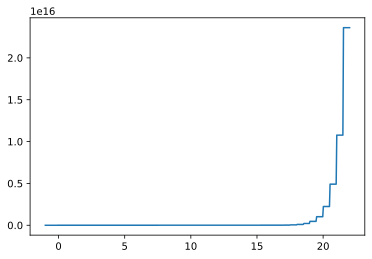

In [12]:
x = np.linspace(-1, 22, 500)
plt.plot(x, sol.kalman_posterior.diffusion_model(x))
plt.show()

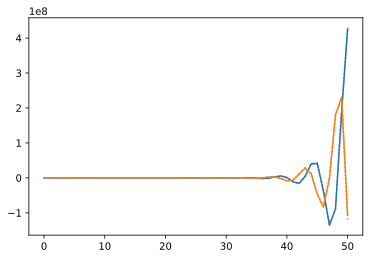

In [13]:
plt.plot(samples.mean(axis=0), color="gray", linestyle="dotted")
plt.plot(means)
plt.show()

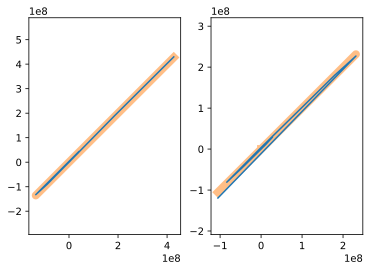

In [14]:
sample_mean = samples.mean(axis=0)
sample_std = samples.std(axis=0)

fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(means[:, 0], sample_mean[:, 0])
ax2.plot(means[:, 1], sample_mean[:, 1])
ax1.plot(means[:, 0], means[:, 0], alpha=0.5, linewidth=8, zorder=0)
ax2.plot(means[:, 1], means[:, 1], alpha=0.5, linewidth=8, zorder=0)

ax1.axis("equal")
ax2.axis("equal")
plt.show()

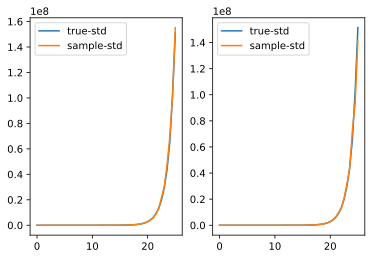

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(locations, stds[:, 0], label="true-std")
ax1.plot(locations, sample_std[:, 0], label="sample-std")
ax1.legend()
ax2.plot(locations, stds[:, 1], label="true-std")
ax2.plot(locations, sample_std[:, 1], label="sample-std")
ax2.legend()
plt.show()

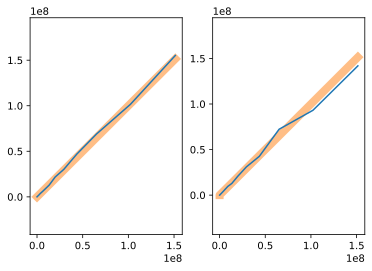

In [16]:
fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(stds[:, 0], sample_std[:, 0])
ax2.plot(stds[:, 1], sample_std[:, 1])
ax1.plot(stds[:, 0], stds[:, 0], alpha=0.5, linewidth=8, zorder=0)
ax2.plot(stds[:, 1], stds[:, 1], alpha=0.5, linewidth=8, zorder=0)
ax1.axis("equal")
ax2.axis("equal")
plt.show()

In [17]:
from probnum import diffeq, filtsmooth, randvars, randprocs, problems
import numpy as np

import matplotlib.pyplot as plt

In [18]:
def f(t, y):
    y1, y2 = y
    return np.array([-0.1*y1+2*y2, -2*y1-0.1*y2])


def df(t, y):
    y1, y2 = y
    return np.array([[-0.1, 2], [-2, -0.1]])


t0 = 0.0
tmax = 25.0
y0 = np.array([2, 0])

ivp = problems.InitialValueProblem(t0=t0, tmax=tmax, y0=y0, f=f, df=df)

In [19]:
prior_process = randprocs.markov.integrator.IntegratedWienerProcess(
    initarg=ivp.t0,
    num_derivatives=4,
    wiener_process_dimension=ivp.dimension,
    forward_implementation="sqrt",
    backward_implementation="sqrt",
)

In [20]:
diffmodel = randprocs.markov.continuous.PiecewiseConstantDiffusion(t0=t0)
rk_init = diffeq.odefilter.initialization_routines.RungeKuttaInitialization()
ode_residual = diffeq.odefilter.information_operators.ODEResidual(4, ivp.dimension)
ek1 = diffeq.odefilter.approx_strategies.EK1()
firststep = diffeq.stepsize.propose_firststep(ivp)
steprule = diffeq.stepsize.AdaptiveSteps(firststep=firststep, atol=1e-3, rtol=1e-5)

solver = diffeq.odefilter.ODEFilter(
    steprule,
    prior_process=prior_process,
    information_operator=ode_residual,
    approx_strategy=ek1,
    initialization_routine=rk_init,
    diffusion_model=diffmodel,
    with_smoothing=True,
)

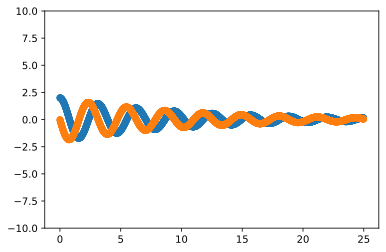

In [21]:
odesol = solver.solve(ivp=ivp)
evalgrid = np.arange(ivp.t0, ivp.tmax, step=0.01)
sol = odesol(evalgrid)

plt.plot(evalgrid, sol.mean, "o-", linewidth=1)
plt.ylim((-10, 10))
plt.show()

# 2-D damped oscillator (Nonlinear)

In [22]:
def f(t, y):
    y1, y2 = y
    return np.array([-0.1*y1**3+2*y2**3, -2*y1**3-0.1*y2**3])


def df(t, y):
    y1, y2 = y
    return np.array([[-0.3*y1**2, 2*y2**2], [-2*y1**2, -0.1*y2**2]])


t0 = 0.0
tmax = 25.0
y0 = np.array([2, 0])
ivp = problems.InitialValueProblem(t0=t0, tmax=tmax, y0=y0, f=f, df=df)

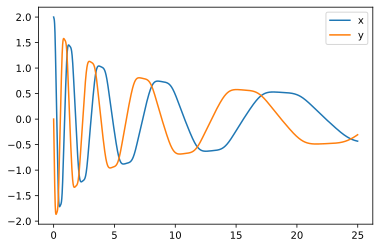

In [23]:
# IBM(1) with EK0,  solving an IVP with adaptive steps works.
sol = probsolve_ivp(t0=t0, tmax=tmax, y0=y0, f=f, df=df)
dt=0.01
evalgrid = np.arange(0, 25, dt)
means = sol(evalgrid).mean

plt.plot(evalgrid, means[:, 0], label="x")
plt.plot(evalgrid, means[:, 1], label="y")
plt.legend(loc="upper right")
plt.show()

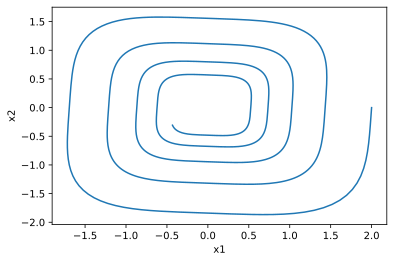

In [24]:
plt.plot(means[:, 0], means[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

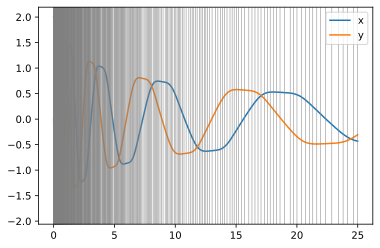

In [25]:
# Let’s visualise the individual steps.
plt.plot(evalgrid, means[:, 0], label="x")
plt.plot(evalgrid, means[:, 1], label="y")
for t in sol.locations:
    plt.axvline(t, linewidth=0.5, color="gray")
plt.legend(loc="upper right")
plt.show()

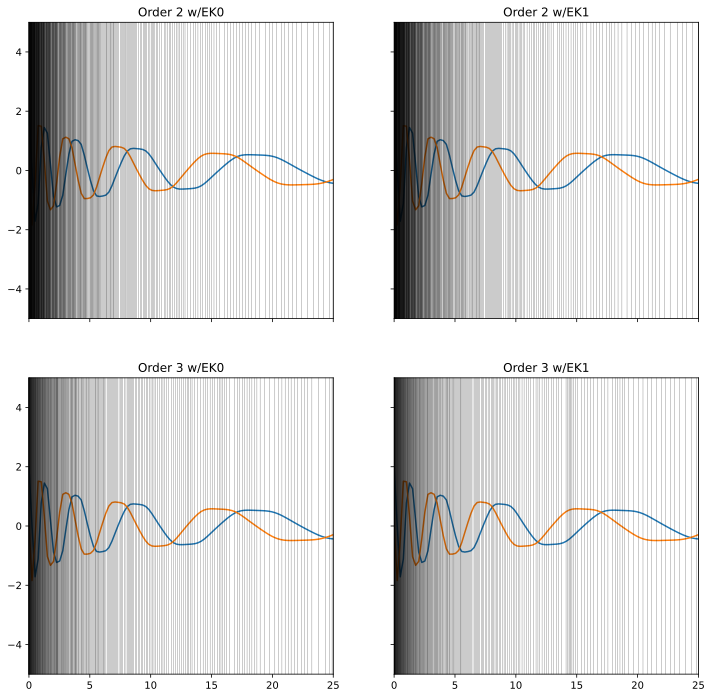

In [26]:
algo_orders = [2, 3]
filters = ["EK0", "EK1"]


fig, ax = plt.subplots(
    nrows=len(algo_orders),
    ncols=len(filters),
    sharex=True,
    sharey=True,
    figsize=(12, 12),
)

evalgrid = np.linspace(t0, tmax, 100)

for idx in range(len(algo_orders)):  # algo_orders in rows
    for jdx in range(len(filters)):  # filters in cols
        sol = probsolve_ivp(
            f,
            t0,
            tmax,
            y0,
            df=df,
            algo_order=algo_orders[idx],
            method=filters[jdx],
        )

        solution = sol(evalgrid)
        ts, means, stds = evalgrid, solution.mean, solution.std
        ax[idx][jdx].plot(ts, means)

        for t in sol.locations:
            ax[idx][jdx].axvline(t, linewidth=0.2, color="black")
        ax[idx][jdx].set_title(f"Order {algo_orders[idx]} w/{filters[jdx]}")
        ax[idx][jdx].set_xlim((t0, tmax))
        ax[idx][jdx].set_ylim((-5, 5))

plt.show()

In [27]:
"""
sol = probsolve_ivp(
    f, t0, tmax, y0, df=df, step=0.01, adaptive=False, diffusion_model="dynamic"
)
"""

'\nsol = probsolve_ivp(\n    f, t0, tmax, y0, df=df, step=0.01, adaptive=False, diffusion_model="dynamic"\n)\n'

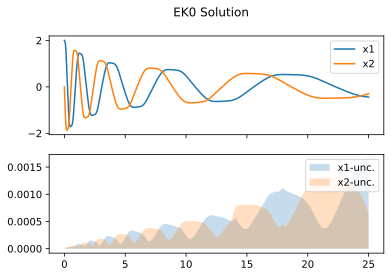

In [28]:

means, stds = sol.states.mean, sol.states.std

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
ax1.plot(sol.locations, means[:, 0], label="x1")
ax1.plot(sol.locations, means[:, 1], label="x2")
ax1.legend()
ax2.fill_between(sol.locations, stds[:, 0], alpha=0.25, label="x1-unc.")
ax2.fill_between(sol.locations, stds[:, 1], alpha=0.25, label="x2-unc.")
ax2.legend()
fig.suptitle("EK0 Solution")
plt.show()

In [29]:
"""
sol = probsolve_ivp(
    f,
    t0,
    tmax,
    y0,
    df=df,
    step=0.5,
    algo_order=1,
    adaptive=False,
    diffusion_model="dynamic",
)
"""

'\nsol = probsolve_ivp(\n    f,\n    t0,\n    tmax,\n    y0,\n    df=df,\n    step=0.5,\n    algo_order=1,\n    adaptive=False,\n    diffusion_model="dynamic",\n)\n'

In [30]:
import numpy as np

from probnum.diffeq import probsolve_ivp


rng = np.random.default_rng(seed=123)

num_samples = 150
locations = np.arange(0.0, 22.1, 0.05)
locations = sol.locations
samples = sol.sample(rng=rng, t=locations, size=num_samples)

solution = sol(locations)
means = solution.mean
stds = solution.std

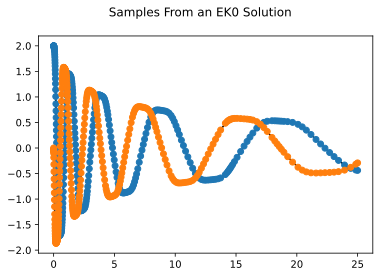

In [31]:
fig, (ax1) = plt.subplots(nrows=1, ncols=1, sharex=True)
for sample in samples[::5]:
    ax1.plot(locations, sample[:, 0], ":", color="C0", linewidth=0.5, alpha=1)
    ax1.plot(locations, sample[:, 1], ":", color="C1", linewidth=0.5, alpha=1)
ax1.plot(locations, means[:, 0], label="x1", color="k")
ax1.plot(locations, means[:, 1], label="x2", color="k")
ax1.fill_between(
    locations,
    means[:, 0] - 3 * stds[:, 0],
    means[:, 0] + 3 * stds[:, 0],
    color="C0",
    alpha=0.3,
)
ax1.fill_between(
    locations,
    means[:, 1] - 3 * stds[:, 1],
    means[:, 1] + 3 * stds[:, 1],
    color="C1",
    alpha=0.3,
)

ax1.plot(sol.locations, sol.states.mean, "o")
fig.suptitle(f"Samples From an EK0 Solution")

plt.show()

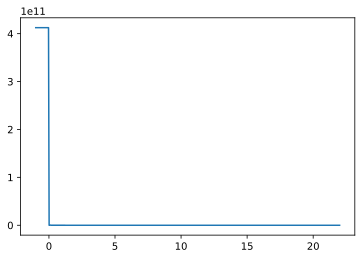

In [32]:
x = np.linspace(-1, 22, 500)
plt.plot(x, sol.kalman_posterior.diffusion_model(x))
plt.show()

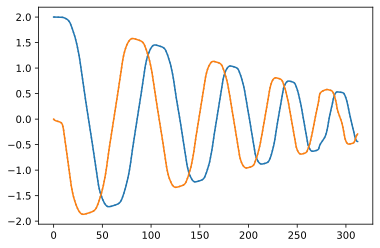

In [33]:
plt.plot(samples.mean(axis=0), color="gray", linestyle="dotted")
plt.plot(means)
plt.show()

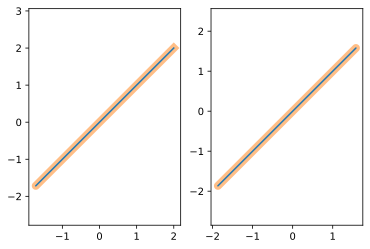

In [34]:
sample_mean = samples.mean(axis=0)
sample_std = samples.std(axis=0)

fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(means[:, 0], sample_mean[:, 0])
ax2.plot(means[:, 1], sample_mean[:, 1])
ax1.plot(means[:, 0], means[:, 0], alpha=0.5, linewidth=8, zorder=0)
ax2.plot(means[:, 1], means[:, 1], alpha=0.5, linewidth=8, zorder=0)

ax1.axis("equal")
ax2.axis("equal")
plt.show()

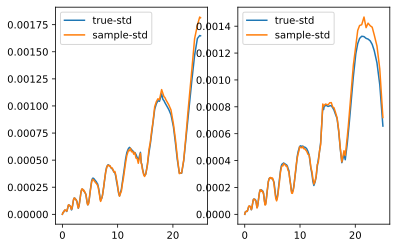

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(locations, stds[:, 0], label="true-std")
ax1.plot(locations, sample_std[:, 0], label="sample-std")
ax1.legend()
ax2.plot(locations, stds[:, 1], label="true-std")
ax2.plot(locations, sample_std[:, 1], label="sample-std")
ax2.legend()
plt.show()

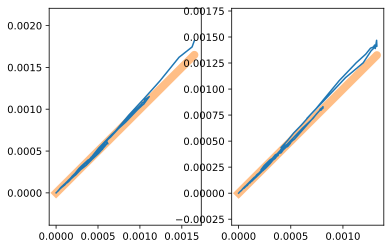

In [36]:
fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(stds[:, 0], sample_std[:, 0])
ax2.plot(stds[:, 1], sample_std[:, 1])
ax1.plot(stds[:, 0], stds[:, 0], alpha=0.5, linewidth=8, zorder=0)
ax2.plot(stds[:, 1], stds[:, 1], alpha=0.5, linewidth=8, zorder=0)
ax1.axis("equal")
ax2.axis("equal")
plt.show()

In [37]:
from probnum import diffeq, filtsmooth, randvars, randprocs, problems
import numpy as np

import matplotlib.pyplot as plt

def f(t, y):
    y1, y2 = y
    return np.array([-0.1*y1**3+2*y2**3, -2*y1**3-0.1*y2**3])


def df(t, y):
    y1, y2 = y
    return np.array([[-0.3*y1**2, 2*y2**2], [-2*y1**2, -0.1*y2**2]])


t0 = 0.0
tmax = 25.0
y0 = np.array([2, 0])
ivp = problems.InitialValueProblem(t0=t0, tmax=tmax, y0=y0, f=f, df=df)

prior_process = randprocs.markov.integrator.IntegratedWienerProcess(
    initarg=ivp.t0,
    num_derivatives=4,
    wiener_process_dimension=ivp.dimension,
    forward_implementation="sqrt",
    backward_implementation="sqrt",
)

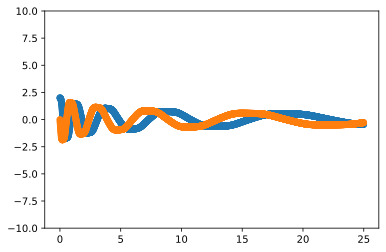

In [38]:
diffmodel = randprocs.markov.continuous.PiecewiseConstantDiffusion(t0=t0)
rk_init = diffeq.odefilter.initialization_routines.RungeKuttaInitialization()
ode_residual = diffeq.odefilter.information_operators.ODEResidual(4, ivp.dimension)
ek1 = diffeq.odefilter.approx_strategies.EK1()
firststep = diffeq.stepsize.propose_firststep(ivp)
steprule = diffeq.stepsize.AdaptiveSteps(firststep=firststep, atol=1e-3, rtol=1e-5)

solver = diffeq.odefilter.ODEFilter(
    steprule,
    prior_process=prior_process,
    information_operator=ode_residual,
    approx_strategy=ek1,
    initialization_routine=rk_init,
    diffusion_model=diffmodel,
    with_smoothing=True,
)

odesol = solver.solve(ivp=ivp)
evalgrid = np.arange(ivp.t0, ivp.tmax, step=0.01)
sol = odesol(evalgrid)

plt.plot(evalgrid, sol.mean, "o-", linewidth=1)
plt.ylim((-10, 10))
plt.show()

# Brusselator

In [39]:
def f(t, y):
    y1, y2 = y
    return np.array([1-4*y1+y1**2*y2, 3*y1-y1**2*y2])


def df(t, y):
    y1, y2 = y
    return np.array([[-4+2*y1*y2,y1**2], [3-2*y1*y2,-y1**2]])


t0 = 0.0
tmax = 25.0
y0 = np.array([0.5, 2])

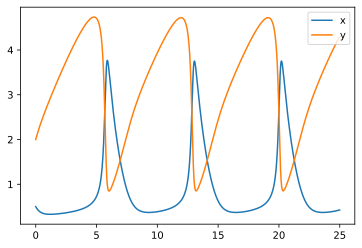

In [40]:
# IBM(1) with EK0,  solving an IVP with adaptive steps works.
sol = probsolve_ivp(f, t0, tmax, y0, df=df, algo_order=4, method="EK1")
dt=0.01
evalgrid = np.arange(0, 25, dt)
means = sol(evalgrid).mean

plt.plot(evalgrid, means[:, 0], label="x")
plt.plot(evalgrid, means[:, 1], label="y")
plt.legend(loc="upper right")
plt.show()

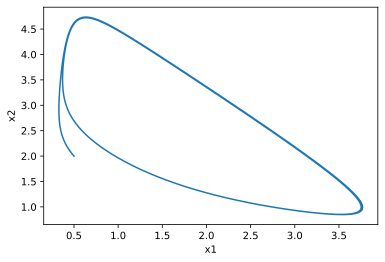

In [41]:
plt.plot(means[:, 0],means[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

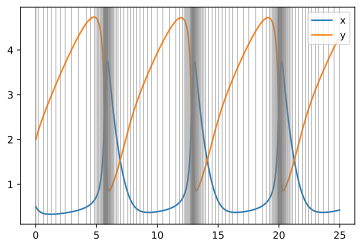

In [42]:
# Let’s visualise the individual steps.
plt.plot(evalgrid, means[:, 0], label="x")
plt.plot(evalgrid, means[:, 1], label="y")
for t in sol.locations:
    plt.axvline(t, linewidth=0.5, color="gray")
plt.legend(loc="upper right")
plt.show()

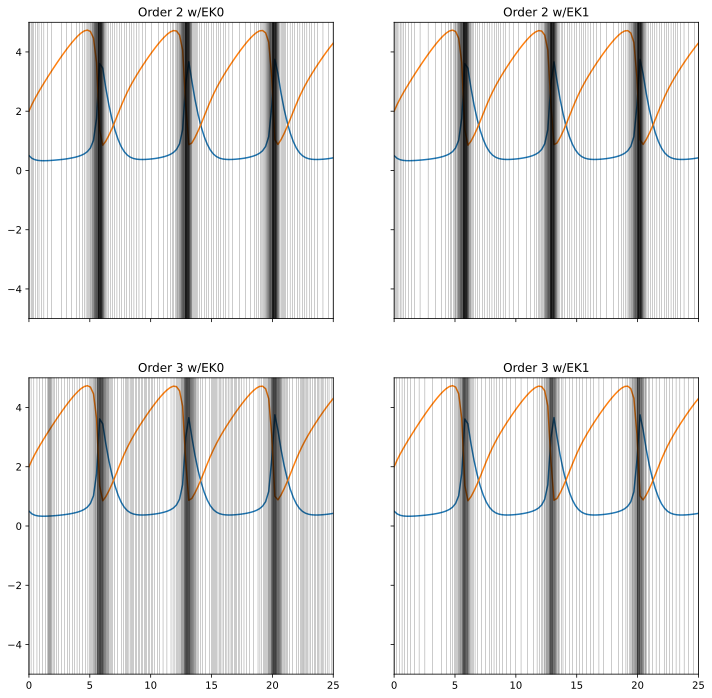

In [43]:
algo_orders = [2, 3]
filters = ["EK0", "EK1"]


fig, ax = plt.subplots(
    nrows=len(algo_orders),
    ncols=len(filters),
    sharex=True,
    sharey=True,
    figsize=(12, 12),
)

evalgrid = np.linspace(t0, tmax, 100)

for idx in range(len(algo_orders)):  # algo_orders in rows
    for jdx in range(len(filters)):  # filters in cols
        sol = probsolve_ivp(
            f,
            t0,
            tmax,
            y0,
            df=df,
            algo_order=algo_orders[idx],
            method=filters[jdx],
        )

        solution = sol(evalgrid)
        ts, means, stds = evalgrid, solution.mean, solution.std
        ax[idx][jdx].plot(ts, means)

        for t in sol.locations:
            ax[idx][jdx].axvline(t, linewidth=0.2, color="black")
        ax[idx][jdx].set_title(f"Order {algo_orders[idx]} w/{filters[jdx]}")
        ax[idx][jdx].set_xlim((t0, tmax))
        ax[idx][jdx].set_ylim((-5, 5))

plt.show()

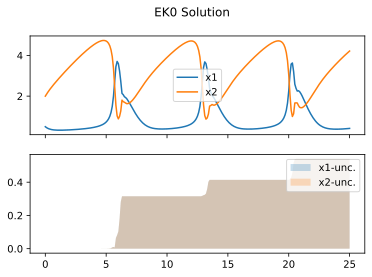

In [44]:
sol = probsolve_ivp(
    f, t0, tmax, y0, df=df, step=0.1, adaptive=False, diffusion_model="dynamic"
)

means, stds = sol.states.mean, sol.states.std

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
ax1.plot(sol.locations, means[:, 0], label="x1")
ax1.plot(sol.locations, means[:, 1], label="x2")
ax1.legend()
ax2.fill_between(sol.locations, stds[:, 0], alpha=0.25, label="x1-unc.")
ax2.fill_between(sol.locations, stds[:, 1], alpha=0.25, label="x2-unc.")
ax2.legend()
fig.suptitle("EK0 Solution")
plt.show()

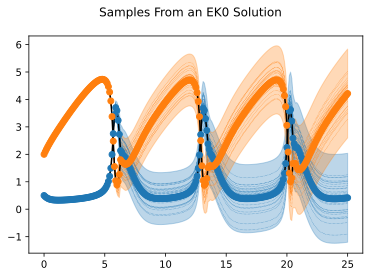

In [45]:
import numpy as np

from probnum.diffeq import probsolve_ivp


rng = np.random.default_rng(seed=123)

num_samples = 150
locations = np.arange(0.0, 22.1, 0.05)
locations = sol.locations
samples = sol.sample(rng=rng, t=locations, size=num_samples)

solution = sol(locations)
means = solution.mean
stds = solution.std

fig, (ax1) = plt.subplots(nrows=1, ncols=1, sharex=True)
for sample in samples[::5]:
    ax1.plot(locations, sample[:, 0], ":", color="C0", linewidth=0.5, alpha=1)
    ax1.plot(locations, sample[:, 1], ":", color="C1", linewidth=0.5, alpha=1)
ax1.plot(locations, means[:, 0], label="x1", color="k")
ax1.plot(locations, means[:, 1], label="x2", color="k")
ax1.fill_between(
    locations,
    means[:, 0] - 3 * stds[:, 0],
    means[:, 0] + 3 * stds[:, 0],
    color="C0",
    alpha=0.3,
)
ax1.fill_between(
    locations,
    means[:, 1] - 3 * stds[:, 1],
    means[:, 1] + 3 * stds[:, 1],
    color="C1",
    alpha=0.3,
)

ax1.plot(sol.locations, sol.states.mean, "o")
fig.suptitle(f"Samples From an EK0 Solution")

plt.show()

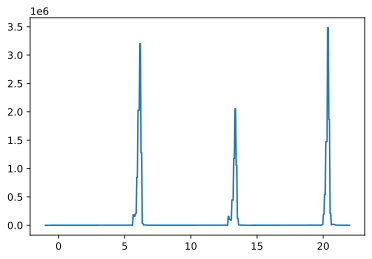

In [46]:
x = np.linspace(-1, 22, 500)
plt.plot(x, sol.kalman_posterior.diffusion_model(x))
plt.show()

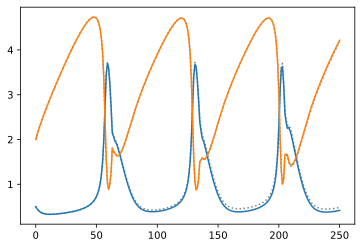

In [47]:
plt.plot(samples.mean(axis=0), color="gray", linestyle="dotted")
plt.plot(means)
plt.show()

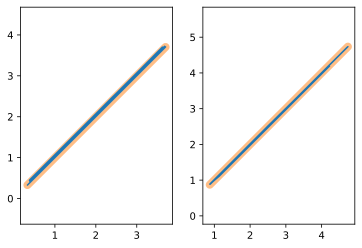

In [48]:
sample_mean = samples.mean(axis=0)
sample_std = samples.std(axis=0)

fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(means[:, 0], sample_mean[:, 0])
ax2.plot(means[:, 1], sample_mean[:, 1])
ax1.plot(means[:, 0], means[:, 0], alpha=0.5, linewidth=8, zorder=0)
ax2.plot(means[:, 1], means[:, 1], alpha=0.5, linewidth=8, zorder=0)

ax1.axis("equal")
ax2.axis("equal")
plt.show()

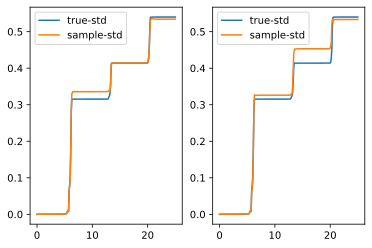

In [49]:
fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(locations, stds[:, 0], label="true-std")
ax1.plot(locations, sample_std[:, 0], label="sample-std")
ax1.legend()
ax2.plot(locations, stds[:, 1], label="true-std")
ax2.plot(locations, sample_std[:, 1], label="sample-std")
ax2.legend()
plt.show()

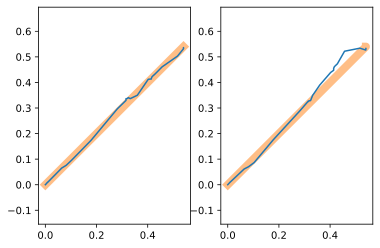

In [50]:
fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(stds[:, 0], sample_std[:, 0])
ax2.plot(stds[:, 1], sample_std[:, 1])
ax1.plot(stds[:, 0], stds[:, 0], alpha=0.5, linewidth=8, zorder=0)
ax2.plot(stds[:, 1], stds[:, 1], alpha=0.5, linewidth=8, zorder=0)
ax1.axis("equal")
ax2.axis("equal")
plt.show()